# Question 1

In [4]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load the dataset

here I imported the data from another file

In [6]:
df = pd.read_csv("RANDOM DATA/Spaceship_Titanic_train.csv")

In [7]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Understand the data

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [9]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [ ]:
df.columns.tolist()

['PassengerId',
 'HomePlanet',
 'CryoSleep',
 'Cabin',
 'Destination',
 'Age',
 'VIP',
 'RoomService',
 'FoodCourt',
 'ShoppingMall',
 'Spa',
 'VRDeck',
 'Name',
 'Transported']

## 3. Exploratory Data Analysis (EDA)

### 3.1 Skewness of Numerical Columns

In [13]:
num_cols = df.select_dtypes(include="number")#this output the numerical columns in the dataset
num_cols.skew()#this output the skewness of the numerical columns in the dataset

Age              0.419097
RoomService      6.333014
FoodCourt        7.102228
ShoppingMall    12.627562
Spa              7.636020
VRDeck           7.819732
dtype: float64

- **`plt.figure()`**: creates a new figure where all subplots will be drawn, and `figsize` specifies the width and height of the figure in inches.
- **`plt.subplot()`**: creates a grid subplot in the format `subplot(rows, cols, position)`
- **`.plot()`**: generates diffrenet types of plots depending on the `kind` attribute.
- **`kind='kde'`**: Kernel Density Estimation plot that is a smoothed version of a histogram that estimates the probability density function of a variable.
- **`plt.title()`**: sets the title for the current subplot.
- **`plt.tight_layout()`**: automatically adjusts subplot spacing to prevent overlapping.
- **`plt.show()`**: displays the final figure containing all the density plots.

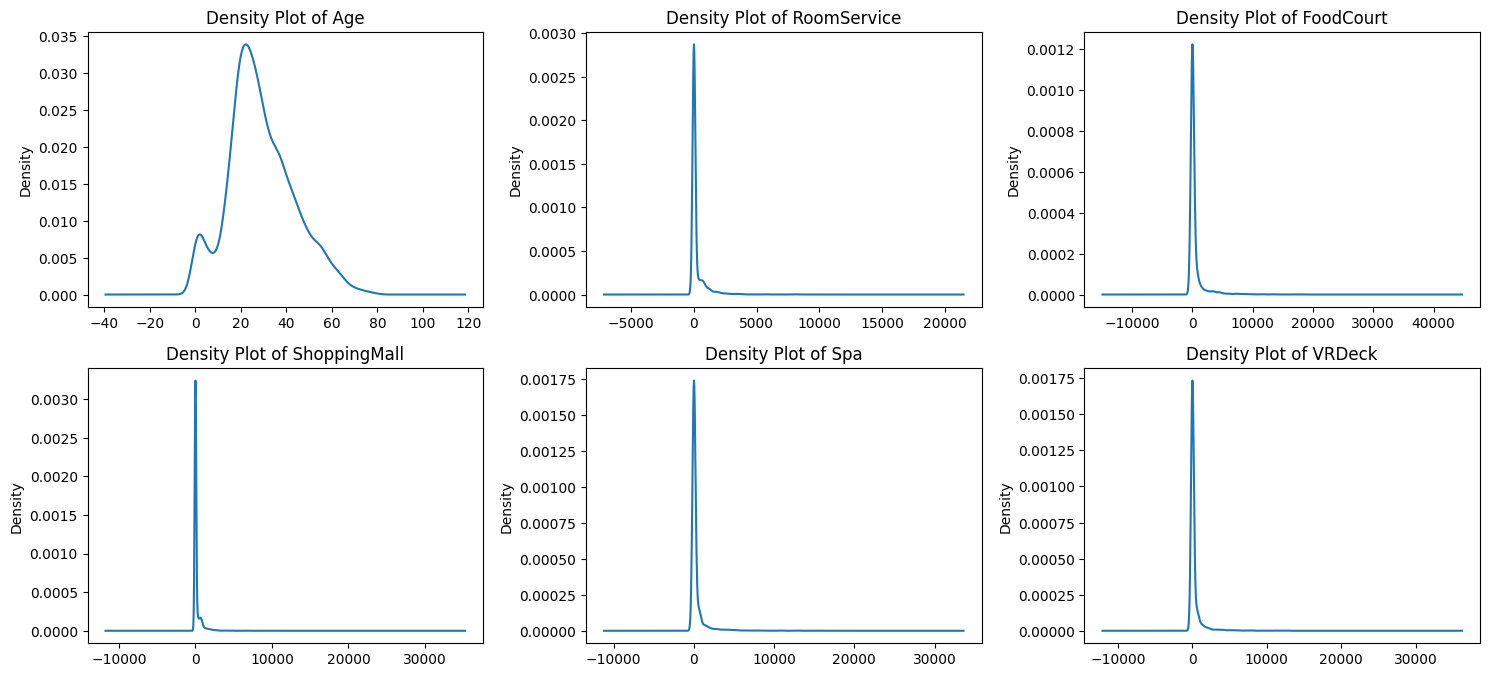

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols.columns.tolist()):
    plt.subplot(3, 3, i+1)
    num_cols[col].plot(kind='kde')
    plt.title(f'Density Plot of {col}')
plt.tight_layout()
plt.show()

### 3.2 Boxplots of Numerical Columns

- **`.dropna()`**: removes any missing values to avoid errors when plotting.
- **`plt.boxplot()`**: creates a boxplot to visualize the distribution of data.
- **`patch_artist=True`**: fills the boxes with color instead of just outlines.
- **`plt.ylabel()`**: adds a y-axis label.

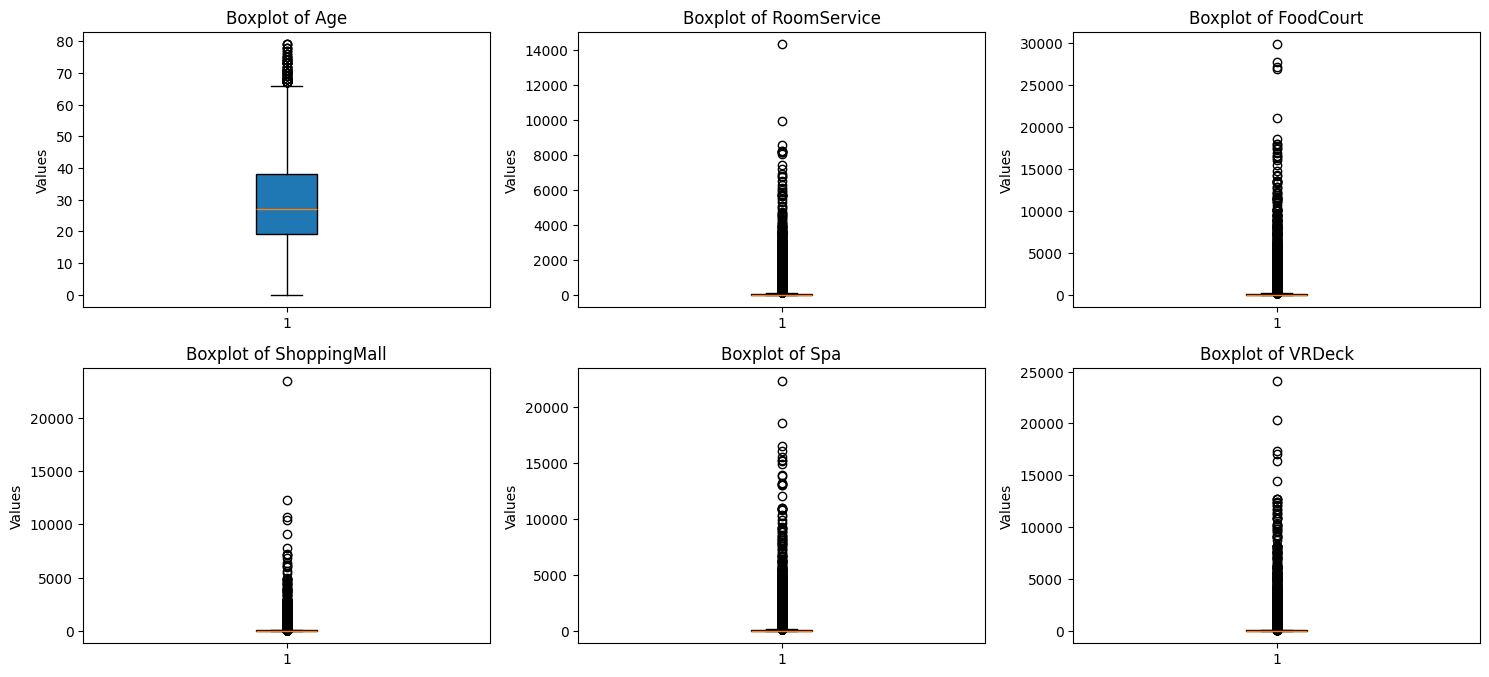

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols.columns, 1):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')
plt.tight_layout()
plt.show()

### 3.3 Barplots for `HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Transported` columns

- **`.plot.bar()`**: generates a bar chart for each column, and each unique value is represented as a bar.

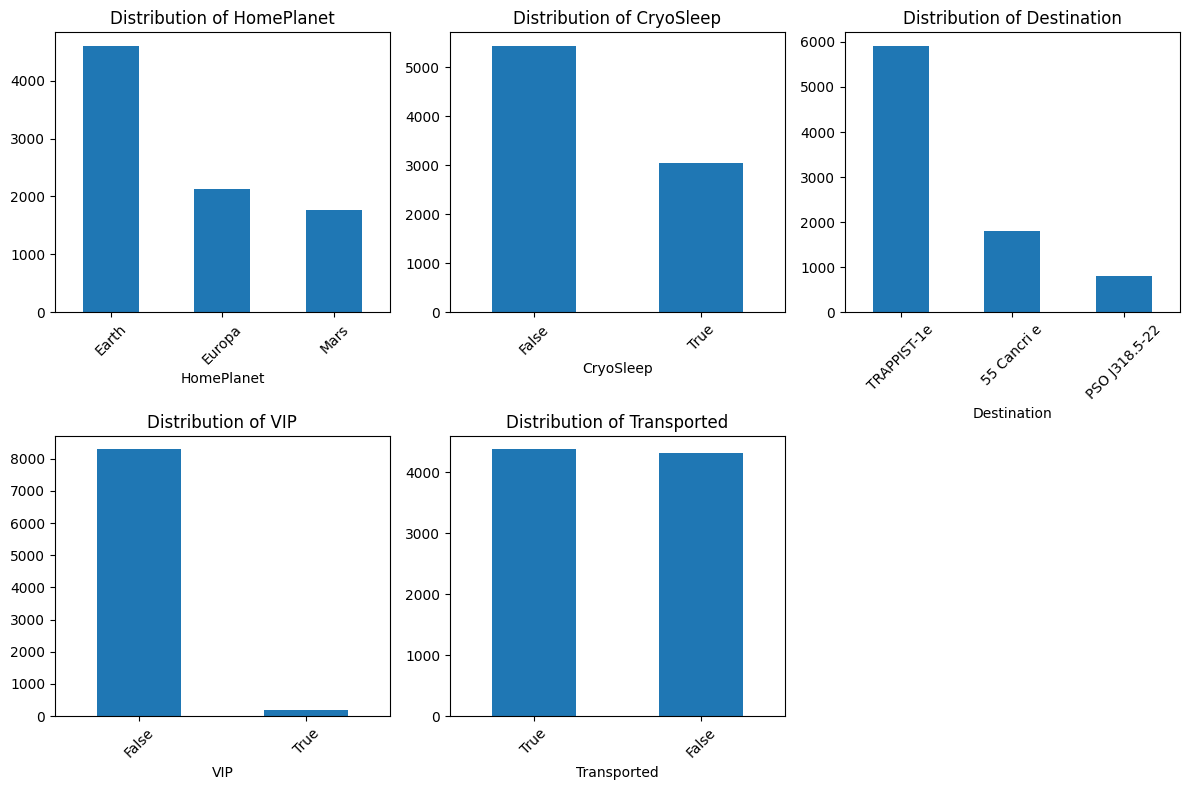

In [ ]:
hist_columns = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Transported"]

plt.figure(figsize=(12, 8))

for i, col in enumerate(hist_columns):
    plt.subplot(2, 3, i+1)
    df[col].value_counts().plot.bar(rot=45)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### 3.4 Cross-tabulation of HomePlanet and Destination

- **`crosstab()`**: creates a cross-tabulation table to show the frequency of combinations between two categorical variables.

In [ ]:
cross_tab = pd.crosstab(df['HomePlanet'], df['Destination'])
print(cross_tab)

Destination  55 Cancri e  PSO J318.5-22  TRAPPIST-1e
HomePlanet                                          
Earth                690            712         3101
Europa               886             19         1189
Mars                 193             49         1475


### 3.6 Heat map of Feature Correlations

- **`.dropna()`**: ensures that we don’t have NaN values affecting correlation calculations.
- **`.map()`**: converts the boolean values into numeric values.
- **`.corr()`**: computes the correlation matrix for the selected columns.
- **`sns.heatmap()`**: used to create heatmaps that is commonly used for visualizing correlation matrices.
- **`annot=True`**: displays the correlation values inside each cell.

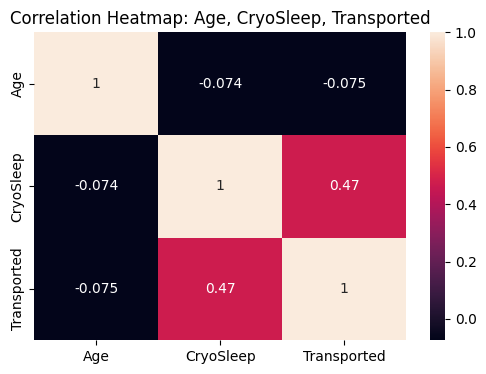

In [ ]:
heatmap_data = df[['Age', 'CryoSleep', 'Transported']].dropna()

# Two different methods to convert boolean data into numerical data (1 and 0)
heatmap_data['CryoSleep'] = heatmap_data['CryoSleep'].map({True: 1, False: 0})
heatmap_data['Transported'] = heatmap_data['Transported'].astype(int)

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data.corr(), annot=True)
print(heatmap_data.corr())
plt.title("Correlation Heatmap: Age, CryoSleep, Transported")
plt.show()

## 4. Identify and handle missing values.

### 4.1 Check for Missing Values

In [ ]:
missing_values = df.isnull().sum()
missing_values


PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

### 4.2 Handle Missing Data

- **Fill missing numerical values with the median.**

**Why use the Median instead of Mean?**
Median is more robust to outliers unlike the mean, the median is not affected by extreme values.

- **`fillna()`**: Replaces **NaN** values in each column with the desired values.
- **`df[number_columns].median()`**: computes the median of each numerical column separately.

In [ ]:
number_columns = num_cols.columns
df[number_columns] = df[number_columns].fillna(df[number_columns].median())

- **Fill missing categorical values with the mode.**

- **`mode()`**: computes the mode (most frequent value) for each categorical columns.
- **`.iloc[0]`**: selects the first mode (if there are multiple values with the highest frequency).

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

C:\Users\jessy\AppData\Local\Temp\ipykernel_60636\4264357618.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


### 4.3 Verify

In [ ]:
df.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

## 5. Detect and address outliers using appropriate statistical methods or visualizations.

### 5.1 Detecting Outliers Using the IQR Method

![image.png](attachment:be92bb04-a9f5-4551-a705-92087b93164c.png)

In [ ]:
for col in number_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Count of outliers in {col}: {outliers.shape[0]}")


Count of outliers in Age: 162
Count of outliers in RoomService: 1906
Count of outliers in FoodCourt: 1916
Count of outliers in ShoppingMall: 1879
Count of outliers in Spa: 1833
Count of outliers in VRDeck: 1849


### 5.2 Handling Outliers

- **Capping (Winsorization): Replace extreme values with the nearest non-outlier values.**
- **`np.where(condition, value_if_true, value_if_false)`**: if the value is below or above the bound it will be repalced, otherwise it keeps its original value without change.

In [ ]:
for col in number_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

### 5.3 Verify

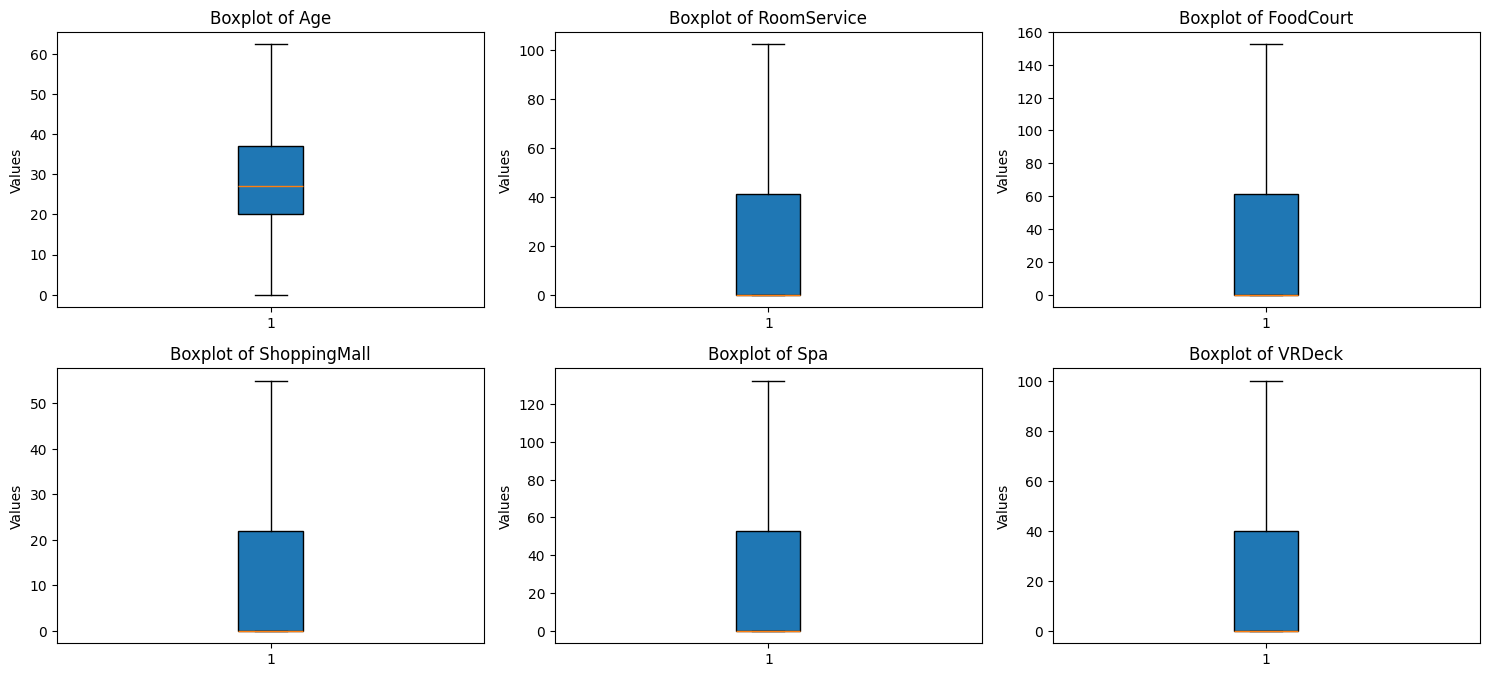

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols.columns.tolist()):
    plt.subplot(3,3,i+1)
    plt.boxplot(df[col].dropna(), patch_artist=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Values')
plt.tight_layout()
plt.show()

## 6. Apply normalization or standardization to variables that require scaling for further analysis or modeling.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

- **Normalization (Min-Max Scaling):** Scales values between 0 and 1.
- **`fit_transform()`**: calculates min & max of each numerical column, then applies Min-Max Scaling.

In [ ]:
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[number_columns] = scaler_minmax.fit_transform(df_minmax[number_columns])

- **Standardization (Z-score scaling):** Centers values around mean 0 with std deviation 1.
- **`fit_transform()`**: calculates mean & standard deviation of each numerical column, then applies Z-score normalization (Standardization).

In [ ]:
# Apply Standardization (Z-score)
scaler_standard = StandardScaler()
df_standard = df.copy()
df_standard[number_columns] = scaler_standard.fit_transform(df_standard[number_columns])

### 6.1 Visualizing Normalized & Standardized Data

- **Plot Normalized vs. Original Data**

- **`sns.histplot()`**: plots a histogram of each numerical column.
- **`kde=Tru`**: adds a Kernel Density Estimate (KDE) curve to show the probability density.
- **`alpha: 0.5`**: transparency for better visualization.
- **`plt.legend()`**: adds a legend to distinguish between the original and scaled distributions.

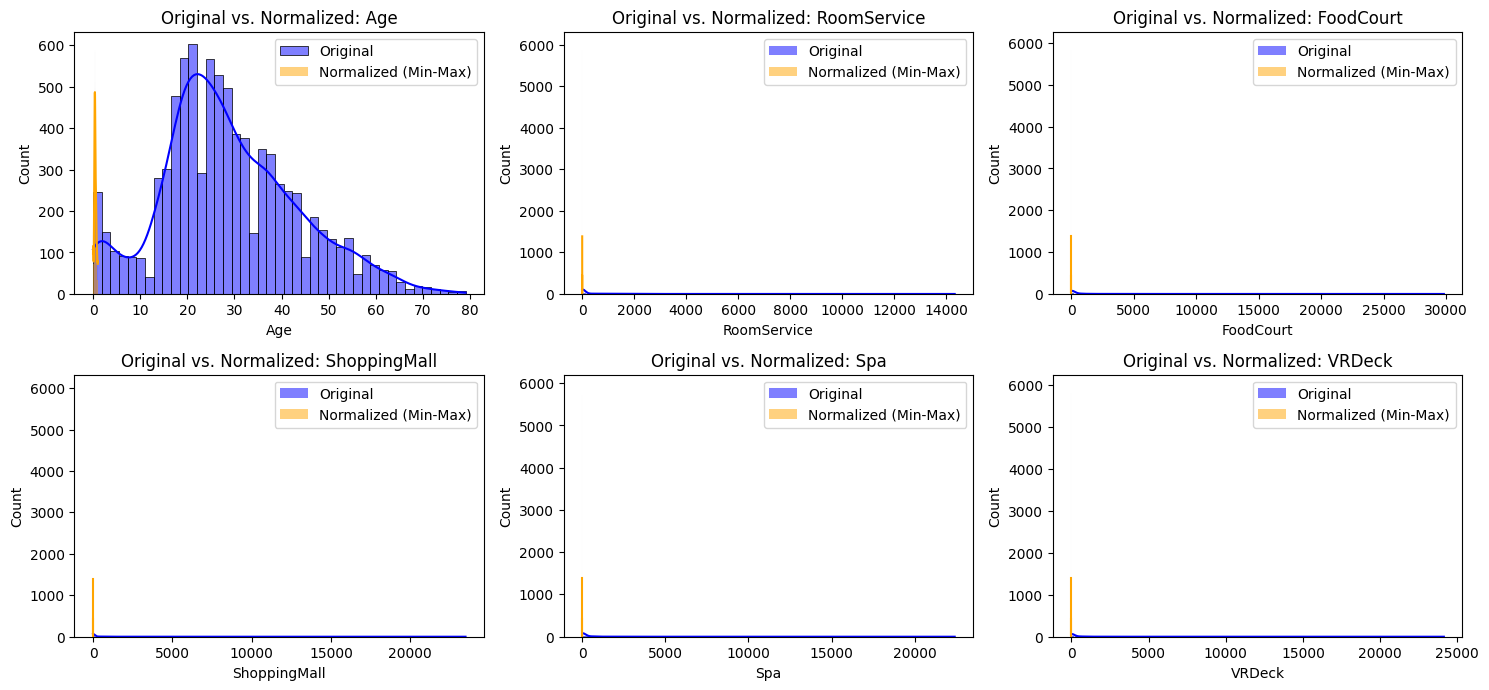

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(number_columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(num_cols[col], label="Original", kde=True, color='blue', alpha=0.5)
    sns.histplot(df_minmax[col], label="Normalized (Min-Max)", kde=True, color='orange', alpha=0.5)
    plt.title(f"Original vs. Normalized: {col}")
    plt.legend()

plt.tight_layout()
plt.show()

- **Plot Standardized vs. Original Data**

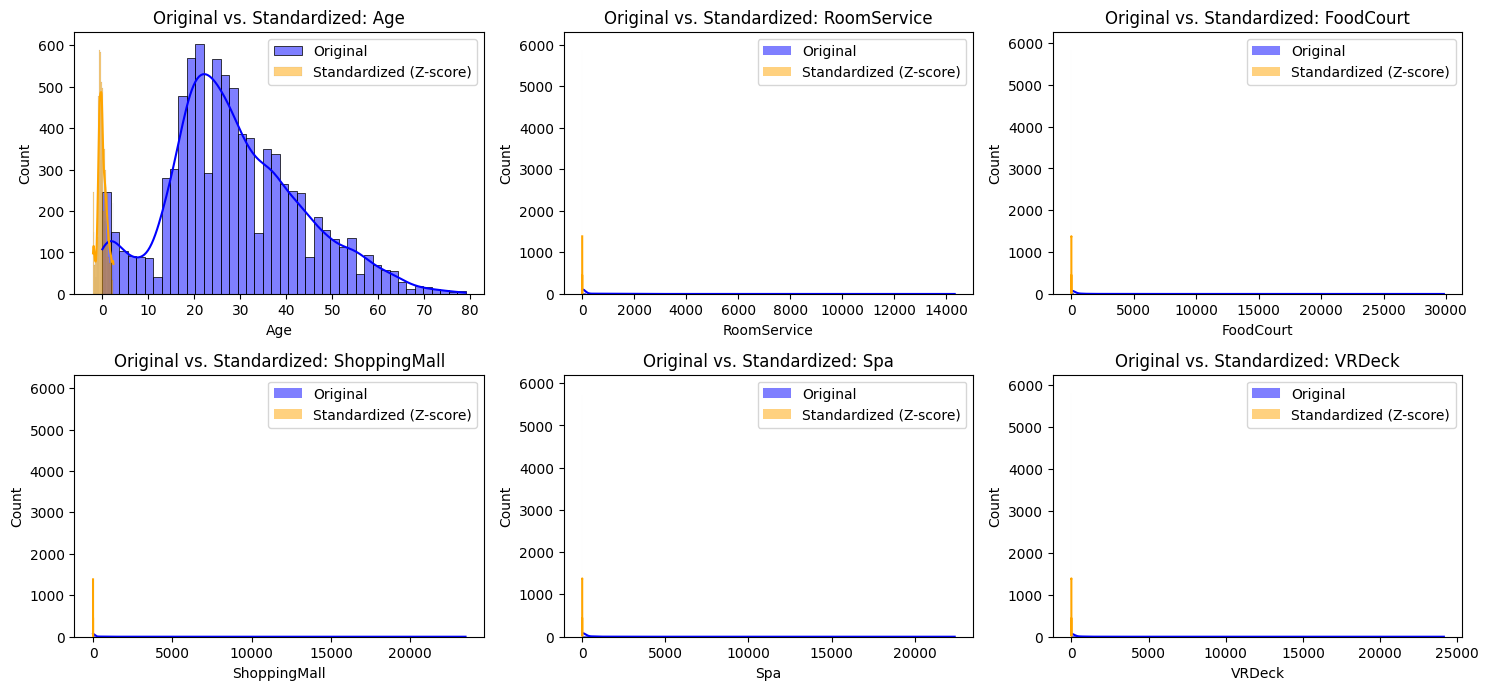

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(number_columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(num_cols[col], label="Original", kde=True, color='blue', alpha=0.5)
    sns.histplot(df_standard[col], label="Standardized (Z-score)", kde=True, color='orange', alpha=0.5)
    plt.title(f"Original vs. Standardized: {col}")
    plt.legend()

plt.tight_layout()
plt.show()

---

# Question 2

In [ ]:
df_iris = pd.read_csv("Iris.csv")

In [ ]:
df_iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris = df_iris.drop(columns=['Id', 'Species'])

In [ ]:
iris.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 1. Min-Max Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
df_min_max_scaled = pd.DataFrame(scaler.fit_transform(iris), columns=iris.columns)

In [ ]:
df_min_max_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667


## 2. Z-score Normalization

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
df_standard_scaled = pd.DataFrame(scaler.fit_transform(iris), columns=iris.columns)

In [ ]:
df_standard_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


## 3. Decimal Scaling Normalization

In [ ]:
import numpy as np

- **`np.max(..., axis=0)`**: fnds the maximum absolute value in each column (column-wise max).
- **`np.log10(max_abs_val)`**: takes the **log base 10** of each max value to find the number of digits.
- **`np.ceil(...)`**: rounds up to the next whole number.

In [ ]:
max_abs_val = np.max(np.abs(iris.values), axis=0)
df_decimal_scaled = iris / 10 ** np.ceil(np.log10(max_abs_val))

In [ ]:
df_decimal_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0.51,0.35,0.14,0.02
1,0.49,0.30,0.14,0.02
2,0.47,0.32,0.13,0.02
3,0.46,0.31,0.15,0.02
4,0.50,0.36,0.14,0.02


---

# Question 3

## Example 1

In [ ]:
ex1_df = pd.DataFrame({
    'Respondent ID': [1, 2, 3, 4, 5],
    'Education Level': ['High School', "Bachelor's", "Master's", 'High School', "Bachelor's"],
    'Income (USD)': [45000, np.nan, np.nan, 32000, 50000]
})

ex1_df

,Respondent ID,Education Level,Income (USD)
0,1,High School,45000.0
1,2,Bachelor's,NaN
2,3,Master's,NaN
3,4,High School,32000.0
4,5,Bachelor's,50000.0


- **`groupby('Education Level')`**: groups the dataset by **Education Level**.
- **`['Income (USD)'].transform('mean')`**: calculates the mean **income** within each education level, then assigns this mean value to each row within the respective group.

In [ ]:
ex1_df['Income (USD)'] = ex1_df['Income (USD)'].fillna(ex1_df.groupby('Education Level')['Income (USD)'].transform('mean'))
ex1_df['Income (USD)'] = ex1_df['Income (USD)'].fillna(ex1_df['Income (USD)'].mean())

In [ ]:
ex1_df

,Respondent ID,Education Level,Income (USD)
0,1,High School,45000.0
1,2,Bachelor's,50000.0
2,3,Master's,44250.0
3,4,High School,32000.0
4,5,Bachelor's,50000.0


## Example 2

In [ ]:
ex2_df = pd.DataFrame({
    'Patient ID': [1, 2, 3, 4, 5],
    'Age': [45, 60, 50, 55, 40],
    'Blood Pressure (mmHg)': [120, np.nan, 130, np.nan, 125],
    'Cholesterol (mg/dL)': [200, 220, np.nan, 210, 190]
})
ex2_df

,Patient ID,Age,Blood Pressure (mmHg),Cholesterol (mg/dL)
0,1,45,120.0,200.0
1,2,60,NaN,220.0
2,3,50,130.0,NaN
3,4,55,NaN,210.0
4,5,40,125.0,190.0


In [ ]:
ex2_df['Blood Pressure (mmHg)'] = ex2_df['Blood Pressure (mmHg)'].fillna(ex2_df['Blood Pressure (mmHg)'].mean())
ex2_df['Cholesterol (mg/dL)'] = ex2_df['Cholesterol (mg/dL)'].fillna(ex2_df['Cholesterol (mg/dL)'].mean())

In [ ]:
ex2_df

,Patient ID,Age,Blood Pressure (mmHg),Cholesterol (mg/dL)
0,1,45,120.0,200.0
1,2,60,125.0,220.0
2,3,50,130.0,205.0
3,4,55,125.0,210.0
4,5,40,125.0,190.0


## Example 3

In [ ]:
ex3_df = pd.DataFrame({
    'Customer ID': [1, 2, 3, 4, 5],
    'Purchase Amount (USD)': [100, 50, 200, 75, 150],
    'Customer Satisfaction (1-10)': [8, np.nan, 3, np.nan, 7]
})
ex3_df

,Customer ID,Purchase Amount (USD),Customer Satisfaction (1-10)
0,1,100,8.0
1,2,50,NaN
2,3,200,3.0
3,4,75,NaN
4,5,150,7.0


In [ ]:
ex3_df_cleaned = ex3_df.dropna(subset=['Customer Satisfaction (1-10)'])

In [ ]:
ex3_df_cleaned

,Customer ID,Purchase Amount (USD),Customer Satisfaction (1-10)
0,1,100,8.0
2,3,200,3.0
4,5,150,7.0
